# EXAM03: Data Science Group Assignment - Iteration 1

**Group name:** [Enter Group Number]

**Student names & numbers:**
* [Name 1] - [Student no.]
* [Name 2] - [Student no.]
* [Name 3] - [Student no.]


---

## 0. Setup

**Import libraries**

In [2]:
# CODE CELL: import the necessary libraries for this iteration
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.float_format', '{:.4f}'.format)

**Load dataset(s)**

In [3]:
# CODE CELL: import the necessary dataset(s) for this iteration
df_observation = pd.read_csv("./data/Dicentrarchus labrax.csv", low_memory=False)
df_habitats = pd.read_csv("./data/habitats_cbs_2022.csv")

df_weather = pd.read_csv("./data/weather.csv", comment='#')

In [4]:
df_weather[["FG", "TG", "RH"]] = df_weather[["FG", "TG", "RH"]] / 10
df_weather["date"] = pd.to_datetime(df_weather["YYYYMMDD"], format="%Y%m%d")
df_weather = df_weather.rename(columns={
    "FG": "wind_speed",
    "TG": "temp_mean",
    "RH": "precipitation"
})
df_weather.head()

,STN,YYYYMMDD,wind_speed,temp_mean,precipitation,date
0,310,20100101,5.6000,0.6000,0.0000,2010-01-01
1,310,20100102,5.8000,1.2000,4.7000,2010-01-02
2,310,20100103,3.5000,-1.5000,1.5000,2010-01-03
3,310,20100104,5.8000,-0.4000,0.2000,2010-01-04
4,310,20100105,5.8000,0.5000,0.0000,2010-01-05


In [5]:
df_observation.head()

,decimalLatitude,decimalLongitude,eventDate,total_observations,speciesgroup_observations,Dicentrarchus labrax
0,50.7500,5.6500,2010-01-01,0.0000,0,0
1,50.7500,5.6500,2010-01-02,26.0000,0,0
2,50.7500,5.6500,2010-01-03,3.0000,0,0
3,50.7500,5.6500,2010-01-04,0.0000,0,0
4,50.7500,5.6500,2010-01-05,0.0000,0,0


In [6]:
df_observation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12558786 entries, 0 to 12558785
Data columns (total 6 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   decimalLatitude            float64
 1   decimalLongitude           float64
 2   eventDate                  object 
 3   total_observations         float64
 4   speciesgroup_observations  int64  
 5   Dicentrarchus labrax       object 
dtypes: float64(3), int64(1), object(2)
memory usage: 574.9+ MB


In [7]:
df_observation.describe()

,decimalLatitude,decimalLongitude,total_observations,speciesgroup_observations
count,12558786.0000,12558786.0000,12558785.0000,12558786.0000
mean,52.2299,5.5329,8.1428,0.0897
std,0.6647,0.8780,62.6530,2.5155
min,3.5000,3.3500,0.0000,0.0000
25%,51.7000,4.9000,0.0000,0.0000
50%,52.2000,5.6500,1.0000,0.0000
75%,52.8000,6.2000,6.0000,0.0000
max,53.5000,53.4000,100040.0000,1011.0000


In [8]:
df_observation['eventDate'] = pd.to_datetime(df_observation['eventDate'])

df_obs_habitat = pd.merge(
    df_observation, 
    df_habitats, 
    on=['decimalLatitude', 'decimalLongitude'], 
    how='left'
)


df_obs_habitat_weather = df_obs_habitat.merge(
    df_weather,
    left_on='eventDate',
    right_on='date',
    how='left'
)

df_obs_habitat_weather = df_obs_habitat_weather.drop(columns=['STN', 'YYYYMMDD', 'date'])
df_obs_habitat_weather.head()

df_obs_habitat_weather['Dicentrarchus labrax'] = pd.to_numeric(df_obs_habitat_weather['Dicentrarchus labrax'], errors='coerce')

In [9]:
# CODE CELL: Missing values in the merged dataset
df_missing = df_obs_habitat_weather[df_obs_habitat_weather.isnull().any(axis=1)]
display(df_missing.head(5)) 

df_no_missing = df_obs_habitat_weather.dropna(subset=['agricultural'])

,decimalLatitude,decimalLongitude,eventDate,total_observations,speciesgroup_observations,Dicentrarchus labrax,agricultural,built,coast,forest,other,sand/heather,water,wetland,main_habitat,wind_speed,temp_mean,precipitation
12558756,3.5500,53.4000,2026-01-01,50.0000,1011,-1.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12558757,3.6500,53.4000,2026-01-02,20.0000,1011,10.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12558758,3.7500,53.4000,2026-01-03,100.0000,1011,10.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12558759,3.5000,53.3000,2026-01-04,20.0000,1011,10.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12558760,3.5000,53.2000,2026-01-05,80.0000,1011,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
# observations with effort but no fish
true_absent = df_no_missing[(df_no_missing['total_observations'] > 0) & (df_no_missing['Dicentrarchus labrax'] == 0)]
print(f"Number of true absent records: {len(true_absent)}")

# no observations at all
no_effort = df_no_missing[df_no_missing['total_observations'] == 0]
print(f"Number of no effort records: {len(no_effort)}")

# clean no effort records
df_clean = df_no_missing[df_no_missing['total_observations'] > 0]

Number of true absent records: 6537558
Number of no effort records: 6019157


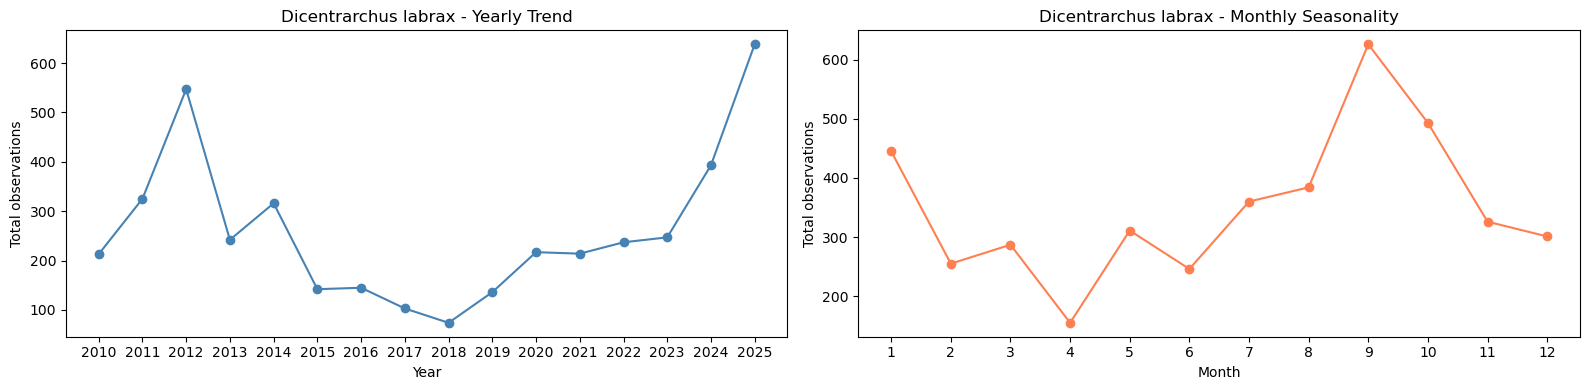

In [11]:
# fixes the SettingWithCopyWarning
df_visual = df_clean.copy()  

df_visual['eventDate'] = pd.to_datetime(df_visual['eventDate'])
df_visual['year'] = df_visual['eventDate'].dt.year
df_visual['month'] = df_visual['eventDate'].dt.month

present_mask = df_visual['Dicentrarchus labrax'] > 0
absent_mask  = df_visual['Dicentrarchus labrax'] == 0

#Year
yearly_species = (
    df_visual.groupby('year')['Dicentrarchus labrax']
    .sum()
    .sort_index()
)

# Month seasonality 
monthly_species = (
    df_visual.groupby('month')['Dicentrarchus labrax']
    .sum()
    .reindex(range(1, 13), fill_value=0)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# left
yearly_species.plot(
    ax=axes[0],
    marker='o',
    color='steelblue'
)

axes[0].set_title('Dicentrarchus labrax - Yearly Trend')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Total observations')

# display all years on x-axis with rotation
axes[0].set_xticks(yearly_species.index)

# right
monthly_species.plot(
    ax=axes[1],
    marker='o',
    color='coral'
)

axes[1].set_title('Dicentrarchus labrax - Monthly Seasonality')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Total observations')
axes[1].set_xticks(range(1, 13))

plt.tight_layout()
plt.show()

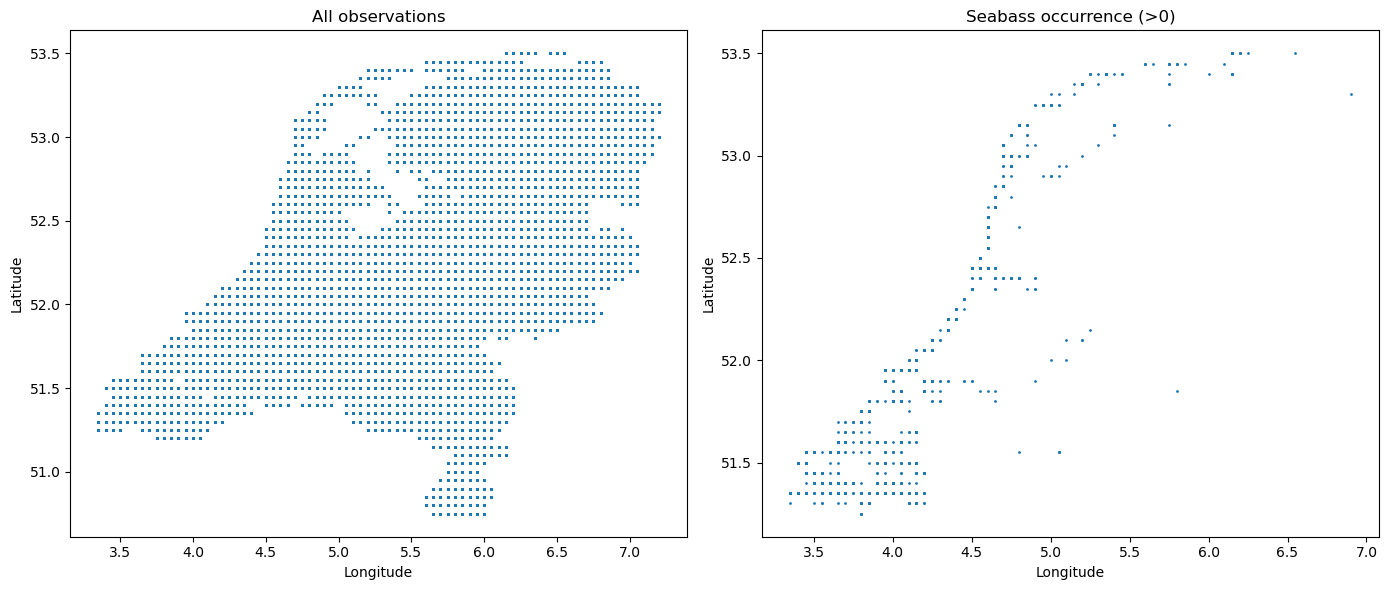

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# left
axes[0].scatter(
    df_visual['decimalLongitude'],
    df_visual['decimalLatitude'],
    s=1
)
axes[0].set_title("All observations")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")

# right
df_seabass = df_visual[present_mask]

axes[1].scatter(
    df_seabass['decimalLongitude'],
    df_seabass['decimalLatitude'],
    s=1
)
axes[1].set_title("Seabass occurrence (>0)")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")

plt.tight_layout()
plt.show()

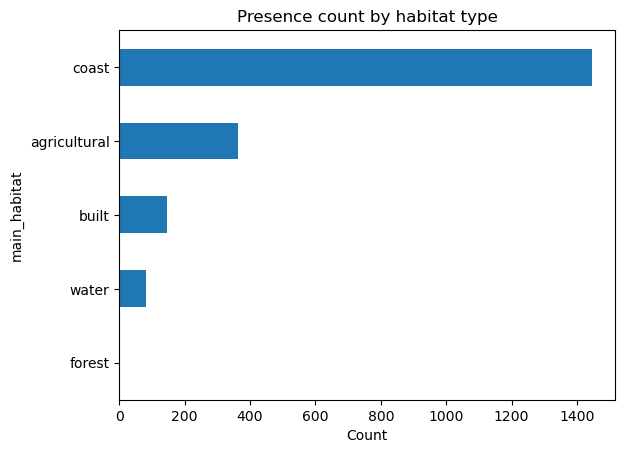

In [13]:
df_visual[present_mask].groupby('main_habitat')['Dicentrarchus labrax'].count().sort_values().plot(kind='barh')
plt.xlabel('Count')
plt.title('Presence count by habitat type')
plt.show()

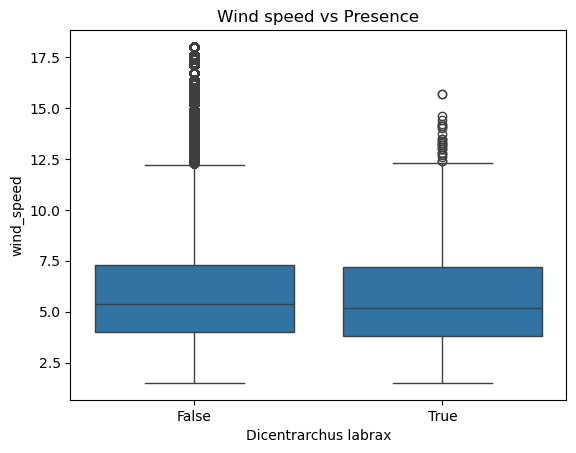

In [14]:
sns.boxplot(data=df_visual, x=present_mask, y='wind_speed')
plt.title("Wind speed vs Presence")
plt.show()

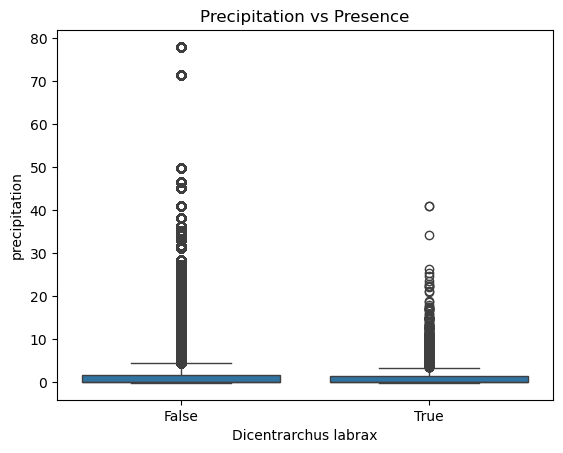

In [15]:
sns.boxplot(data=df_visual, x=present_mask, y='precipitation')
plt.title("Precipitation vs Presence")
plt.show()

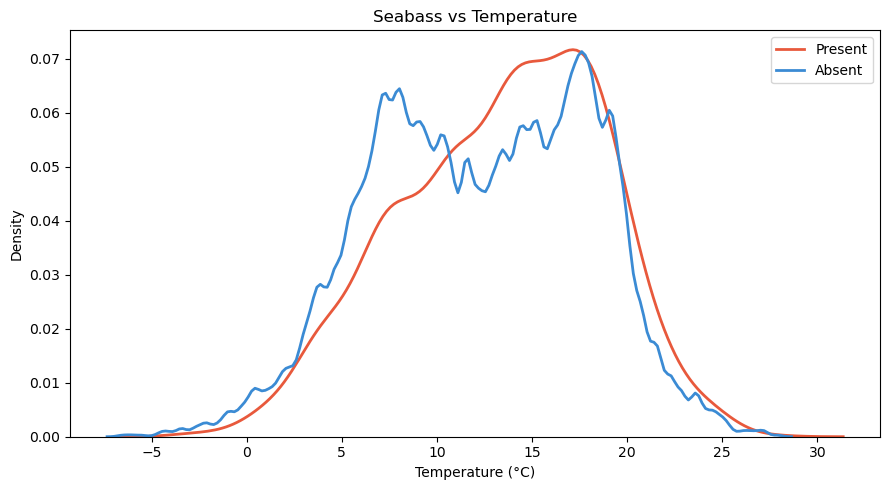

In [16]:
present = df_visual[present_mask]['temp_mean'].dropna()
absent  = df_visual[absent_mask]['temp_mean'].dropna()

fig, ax = plt.subplots(figsize=(9, 5))

sns.kdeplot(present, ax=ax, color='#E8593C', linewidth=2, label='Present')
sns.kdeplot(absent,  ax=ax, color='#3B8BD4', linewidth=2, label='Absent')

ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Density')
ax.set_title('Seabass vs Temperature')
ax.legend()

plt.tight_layout()
plt.show()

In [17]:
df_clean.head(5)

,decimalLatitude,decimalLongitude,eventDate,total_observations,speciesgroup_observations,Dicentrarchus labrax,agricultural,built,coast,forest,other,sand/heather,water,wetland,main_habitat,wind_speed,temp_mean,precipitation
1,50.7500,5.6500,2010-01-02,26.0000,0,0.0000,1.7747,0.0568,0.0000,0.0616,0.0582,0.0000,0.4688,0.0000,agricultural,5.8000,1.2000,4.7000
2,50.7500,5.6500,2010-01-03,3.0000,0,0.0000,1.7747,0.0568,0.0000,0.0616,0.0582,0.0000,0.4688,0.0000,agricultural,3.5000,-1.5000,1.5000
5,50.7500,5.6500,2010-01-06,1.0000,0,0.0000,1.7747,0.0568,0.0000,0.0616,0.0582,0.0000,0.4688,0.0000,agricultural,4.9000,-2.1000,-0.1000
7,50.7500,5.6500,2010-01-08,1.0000,0,0.0000,1.7747,0.0568,0.0000,0.0616,0.0582,0.0000,0.4688,0.0000,agricultural,5.4000,-3.7000,-0.1000
12,50.7500,5.6500,2010-01-13,18.0000,0,0.0000,1.7747,0.0568,0.0000,0.0616,0.0582,0.0000,0.4688,0.0000,agricultural,7.0000,-0.4000,2.0000


In [18]:
# --- STEP 2.4: DATA CONSTRUCTION ---

# Define the target variable: 1 if present, 0 if absent
df_clean['target'] = (df_clean['Dicentrarchus labrax'] > 0).astype(int)

# Check the target distribution to understand class imbalance
print("Target Distribution:")
print(df_clean['target'].value_counts(normalize=True))

# Apply One-Hot Encoding to 'main_habitat'
df_final = pd.get_dummies(df_clean, columns=['main_habitat'], prefix='main_hab')

bool_cols = df_final.select_dtypes(include='bool').columns
df_final[bool_cols] = df_final[bool_cols].astype(int)

# Confirm the new columns created by OHE
print("\nNew columns after One-Hot Encoding:")
print([col for col in df_final.columns if 'main_hab' in col])

# Show the first few rows to verify
df_final.head()

C:\Users\sasda\AppData\Local\Temp\ipykernel_6636\3600526012.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['target'] = (df_clean['Dicentrarchus labrax'] > 0).astype(int)


Target Distribution:
target
0   0.9997
1   0.0003
Name: proportion, dtype: float64

New columns after One-Hot Encoding:
['main_hab_agricultural', 'main_hab_built', 'main_hab_coast', 'main_hab_forest', 'main_hab_other', 'main_hab_sand/heather', 'main_hab_water', 'main_hab_wetland']


,decimalLatitude,decimalLongitude,eventDate,total_observations,speciesgroup_observations,Dicentrarchus labrax,agricultural,built,coast,forest,...,precipitation,target,main_hab_agricultural,main_hab_built,main_hab_coast,main_hab_forest,main_hab_other,main_hab_sand/heather,main_hab_water,main_hab_wetland
1,50.7500,5.6500,2010-01-02,26.0000,0,0.0000,1.7747,0.0568,0.0000,0.0616,...,4.7000,0,1,0,0,0,0,0,0,0
2,50.7500,5.6500,2010-01-03,3.0000,0,0.0000,1.7747,0.0568,0.0000,0.0616,...,1.5000,0,1,0,0,0,0,0,0,0
5,50.7500,5.6500,2010-01-06,1.0000,0,0.0000,1.7747,0.0568,0.0000,0.0616,...,-0.1000,0,1,0,0,0,0,0,0,0
7,50.7500,5.6500,2010-01-08,1.0000,0,0.0000,1.7747,0.0568,0.0000,0.0616,...,-0.1000,0,1,0,0,0,0,0,0,0
12,50.7500,5.6500,2010-01-13,18.0000,0,0.0000,1.7747,0.0568,0.0000,0.0616,...,2.0000,0,1,0,0,0,0,0,0,0


In [19]:
# --- STEP 2.5: DATA FORMAT CONVERSION ---

# Define the feature columns: 8 habitat percentages + 8 OHE habitat indicators = 16 features
habitat_percentages = ['agricultural', 'built', 'coast', 'forest', 'other', 'sand/heather', 'water', 'wetland']
encoded_habitats = [col for col in df_final.columns if 'main_hab' in col]

all_features = habitat_percentages + encoded_habitats
# Create the feature matrix X and target vector y
X = df_final[all_features]
y = df_final['target']

# Convert to NumPy arrays for Scikit-learn
X_array = X.values
y_array = y.values

# Verify the shapes and show a sample
print("DataFrame Representation (X head - showing all 16 features):")
display(X.head())

print(f"\nNumPy Array Representation:")
print(f"X array shape: {X_array.shape}")
print(f"y array shape: {y_array.shape}")
print(f"X array sample (first row):\n{X_array[0]}")

DataFrame Representation (X head - showing all 16 features):


,agricultural,built,coast,forest,other,sand/heather,water,wetland,main_hab_agricultural,main_hab_built,main_hab_coast,main_hab_forest,main_hab_other,main_hab_sand/heather,main_hab_water,main_hab_wetland
1,1.7747,0.0568,0.0000,0.0616,0.0582,0.0000,0.4688,0.0000,1,0,0,0,0,0,0,0
2,1.7747,0.0568,0.0000,0.0616,0.0582,0.0000,0.4688,0.0000,1,0,0,0,0,0,0,0
5,1.7747,0.0568,0.0000,0.0616,0.0582,0.0000,0.4688,0.0000,1,0,0,0,0,0,0,0
7,1.7747,0.0568,0.0000,0.0616,0.0582,0.0000,0.4688,0.0000,1,0,0,0,0,0,0,0
12,1.7747,0.0568,0.0000,0.0616,0.0582,0.0000,0.4688,0.0000,1,0,0,0,0,0,0,0



NumPy Array Representation:
X array shape: (6539599, 16)
y array shape: (6539599,)
X array sample (first row):
[1.7747 0.0568 0.     0.0616 0.0582 0.     0.4688 0.     1.     0.
 0.     0.     0.     0.     0.     0.    ]


In [88]:
# --- STEP 3.1: PREPARING THE FEATURES ---

# We use df_final because it already has the One-Hot Encoded habitat columns
df_ml = df_final.copy()

# Add Sin/Cos transformation for time to capture seasonality correctly
df_ml['year'] = df_ml['eventDate'].dt.year
df_ml['month'] = df_ml['eventDate'].dt.month
df_ml['month_sin'] = np.sin(2 * np.pi * df_ml['month'] / 12)
df_ml['month_cos'] = np.cos(2 * np.pi * df_ml['month'] / 12)

# DEFINE THE TARGET (y) AND FEATURES (X)
# CRITICAL: We drop 'target' and raw counts to prevent DATA LEAKAGE
cols_to_drop = [
    'Dicentrarchus labrax',       # Raw counts
    'target',                     # THE ANSWER (removing this fixes the 1.00 scores)
    'eventDate',                  # Non-numeric
    'month',                      # Replaced by sin/cos
    'decimalLatitude',            # Excluded to avoid overfitting to map dots
    'decimalLongitude'            # Excluded to avoid overfitting to map dots
]

y = df_ml['target']
X = df_ml.drop(columns=cols_to_drop)

print(f"Features being used: {X.columns.tolist()}")

Features being used: ['total_observations', 'speciesgroup_observations', 'agricultural', 'built', 'coast', 'forest', 'other', 'sand/heather', 'water', 'wetland', 'salinity_mean', 'temperature_mean', 'main_hab_agricultural', 'main_hab_built', 'main_hab_coast', 'main_hab_forest', 'main_hab_other', 'main_hab_sand/heather', 'main_hab_water', 'main_hab_wetland', 'year', 'month_sin', 'month_cos']


In [89]:
# --- STEP 3.2: FULL SCALE TEST DESIGN (ALL DATA) ---
from sklearn.model_selection import train_test_split
import gc

# Clear any old variables to free up RAM
gc.collect()

print("Splitting all 12.5 million rows... this might take a minute.")

# We use the X and y we defined in Step 3.1
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"Full Training set: {X_train.shape[0]} rows")
print(f"Full Testing set: {X_test.shape[0]} rows")

Splitting all 12.5 million rows... this might take a minute.
Full Training set: 5231679 rows
Full Testing set: 1307920 rows


In [90]:
# --- STEP 3.3: MEMORY-SAFE BIG RUN ---
from sklearn.ensemble import RandomForestClassifier

# We add 'max_samples' and 'max_depth' so your 16GB RAM doesn't crash
rf_full = RandomForestClassifier(
    n_estimators=100, 
    random_state=42, 
    class_weight='balanced', 
    n_jobs=-1,           # Using all 14 cores of your i9
    max_samples=0.2,     # RAM SAFETY: Optimization
    max_depth=15,        # RAM SAFETY: Prevents memory overflow
    verbose=1            # Shows you progress
)

print("TRAINING STARTED. CLOSE YOUR BROWSER NOW!")
rf_full.fit(X_train, y_train)

TRAINING STARTED. CLOSE YOUR BROWSER NOW!


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:   11.4s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   29.6s finished


RandomForestClassifier(class_weight='balanced', max_depth=15, max_samples=0.2,
                       n_jobs=-1, random_state=42, verbose=1)

[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.3s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.8s finished


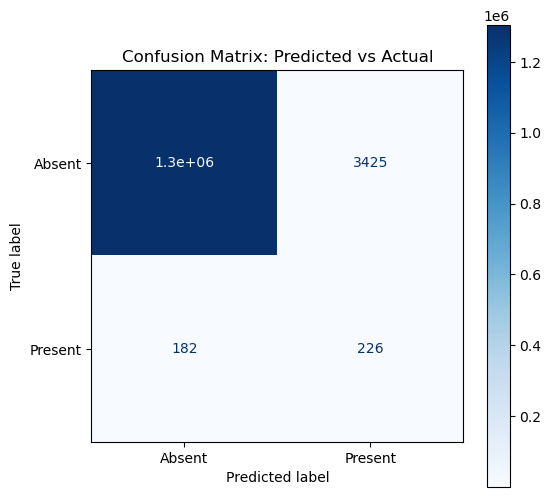

In [91]:
# CODE CELL: Confusion Matrix Visualization
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred_full = rf_full.predict(X_test)
cm = confusion_matrix(y_test, y_pred_full)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Absent', 'Present'])

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap='Blues', ax=ax)
plt.title('Confusion Matrix: Predicted vs Actual')
plt.show()

/var/folders/pn/ch7h23814fl2b5bmht0fv7_w0000gn/T/ipykernel_68373/3317749449.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


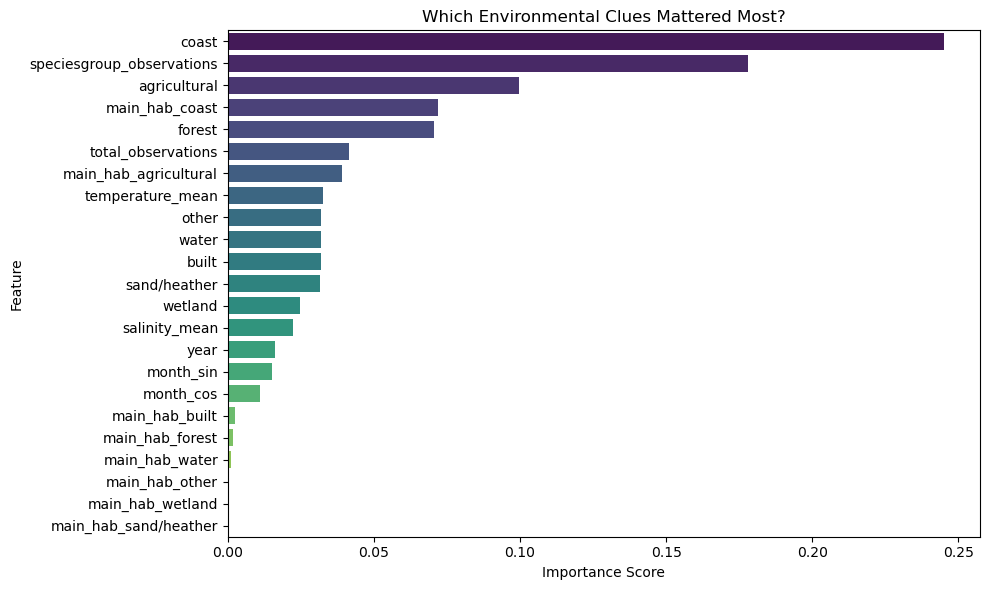

In [92]:
# CODE CELL: Feature Importance (Which clues mattered most?)
importances = rf_full.feature_importances_
feature_names = X_train.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Which Environmental Clues Mattered Most?')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [93]:
# --- STEP 3.4: PRINT CLASSIFICATION REPORT ---
from sklearn.metrics import classification_report

print("\n--- Model Performance Report ---")
# y_test are the real answers, y_pred_full are the AI's guesses
print(classification_report(y_test, y_pred_full))


--- Model Performance Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1307512
           1       0.06      0.55      0.11       408

    accuracy                           1.00   1307920
   macro avg       0.53      0.78      0.55   1307920
weighted avg       1.00      1.00      1.00   1307920



---

## 1. Business Understanding
*Rubric: LO 6.4D (Reflection on Process)*

**Situation description**

*Describe the Nebula Brokerage pricing problem. Why is their current "gut feeling" approach a risk?.*

**Business objective(s)**

*Justify why a data-driven baseline is needed*

**Data mining goal(s)**

*Explain what type of modeling task this is and why.*

**Success criteria**

*Determine success criteria for this iteration (the benchmark)*

---

## 2. Data Understanding
*Rubric: LO 7.3Q (Visuals) & LO 6.4C (Process)*

**Data exploration**

*Include summary statistics and descriptions of data types below. Describe your findings.*

In [26]:
# CODE CELL: Show basic statistics and information

**Visualizations and patterns**

*Discover patterns in the data by creating visualizations. Create at least a histogram of Galactic_Credits. Describe your observations.*

In [27]:
# CODE CELL: Generate visualizations (e.g., scatter plots, histograms)

**Data insights and data quality**
* **Insights:** What are the key trends? What does the distribution look like? What does that mean? 
* **Quality issues:** Document missing values, duplicates, outliers, etc.

---

## 3. Data Preparation
*Rubric: LO 6.4C (Data Science Steps)*

**Cleaning and preprocessing**
*Describe and justify steps taken (e.g., imputation, handling outliers, fixing other errors).*

In [28]:
# CODE CELL: Data cleaning and preprocessing steps

**Adjusting dataset (optional)**
*If you adjusted the dataset for modeling in additional ways, describe that here*

In [29]:
# OPTIONAL CODE CELL: Additional preprocessing steps

---

## 4. Modeling
*Rubric: LO 6.4C (Data Science Steps)*

**Model setup**
*Describe and justify the creation of your simple benchmark model to predict Galactic_Credits*

In [30]:
# CODE CELL: Model training and setup code

**Testing and performance**
*Describe how you tested the model and interpret the metrics. Make sure to present the metrics in a clear overview.*

In [31]:
# CODE CELL: Model evaluation code

---

## 5. Evaluation
*Rubric: LO 6.4C (Results vs. Objectives)*

**Assessment against succes criteria** 
*What is the difference between the metrics? What does this mean? Did you meet the goals set in the Business Understanding?*

**Key findings and limitations**
*What did you learn? What are the limitations of this current model?*

---

## 6 Personal Contribution
*Rubric: LO 7.3P (Equal Contribution)*

| Student name | Contribution | Personal lessons learned |
| :--- | :--- | :--- |
| Student name 1 | *Contribution description* | *Personal lessons learned this iteration* |
| Student name 2 | *Contribution description* | *Personal lessons learned this iteration* |
| Student name 3 | *Contribution description* | *Personal lessons learned this iteration* |